In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import shutil

src = "/content/drive/MyDrive/Colab Notebooks/data/graph_dataset.tar.gz"
dst = "/content/graph_dataset.tar.gz"

shutil.copy(src, dst)

print("✅ Copied dataset to local runtime")

✅ Copied dataset to local runtime


In [10]:
import tarfile

with tarfile.open("graph_dataset.tar.gz", "r:gz") as tar:
    tar.extractall(path="/content/")

print("✅ Extraction complete")

/tmp/ipykernel_1751/212617451.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content/")


FileExistsError: [Errno 17] File exists: '/content/graph_dataset'

In [20]:
import os

files = os.listdir("graph_dataset")
print("Total graphs:", len(files))

Total graphs: 386544


In [21]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.5 MB/s eta 0:00:00


In [22]:
import torch
from torch_geometric.data import Dataset

class GraphDataset(Dataset):
    def __init__(self, root):
        super().__init__()
        self.files = sorted([
            f"{root}/{f}" for f in os.listdir(root) if f.endswith(".pt")
        ])

    def len(self):
        return len(self.files)

    def get(self, idx):
        return torch.load(self.files[idx], weights_only=False)

In [23]:
dataset = GraphDataset("graph_dataset")

subset_size = 50000   # start here
dataset = dataset[:subset_size]

print("Using subset:", len(dataset))

Using subset: 50000


In [24]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

In [25]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [26]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import NNConv, global_mean_pool

class NNConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.edge_mlp1 = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 1 * 64)
        )
        self.conv1 = NNConv(1, 64, self.edge_mlp1, aggr='mean')

        self.edge_mlp2 = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64 * 64)
        )
        self.conv2 = NNConv(64, 64, self.edge_mlp2, aggr='mean')

        self.edge_mlp3 = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64 * 64)
        )
        self.conv3 = NNConv(64, 64, self.edge_mlp3, aggr='mean')

        self.lin = nn.Linear(64, 2)

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        return self.lin(x)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NNConvNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss()

In [28]:
def train():
    model.train()
    total_loss = 0

    for data in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [29]:
from sklearn.metrics import roc_auc_score

def evaluate(loader):
    model.eval()

    y_true, y_prob = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)

            prob = torch.softmax(out, dim=1)[:, 1]

            y_true.extend(data.y.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

    return roc_auc_score(y_true, y_prob)

In [30]:
train_losses = []
val_aucs = []

best_auc = 0

for epoch in range(10):
    loss = train()
    val_auc = evaluate(val_loader)

    train_losses.append(loss)
    val_aucs.append(val_auc)

    print(f"Epoch {epoch}")
    print(f"Loss: {loss:.4f} | Val AUC: {val_auc:.4f}")

    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_model.pt")
        print("💾 Saved best model")

/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [5962], which does not match the required output shape [5962, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /pytorch/aten/src/ATen/native/Resize.cpp:31.)
  value = torch.cat(values, dim=cat_dim or 0, out=out)
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [4724], which does not match the required output shape [4724, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements w

Epoch 0
Loss: 0.8588 | Val AUC: 0.7744
💾 Saved best model


/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [2682], which does not match the required output shape [2682, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /pytorch/aten/src/ATen/native/Resize.cpp:31.)
  value = torch.cat(values, dim=cat_dim or 0, out=out)
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [4748], which does not match the required output shape [4748, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements w

Epoch 1
Loss: 0.4593 | Val AUC: 0.7848
💾 Saved best model


/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [3784], which does not match the required output shape [3784, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /pytorch/aten/src/ATen/native/Resize.cpp:31.)
  value = torch.cat(values, dim=cat_dim or 0, out=out)
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [4756], which does not match the required output shape [4756, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements w

...

Epoch 7
Loss: 0.4389 | Val AUC: 0.7988


/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [3924], which does not match the required output shape [3924, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /pytorch/aten/src/ATen/native/Resize.cpp:31.)
  value = torch.cat(values, dim=cat_dim or 0, out=out)
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [4550], which does not match the required output shape [4550, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements w

Epoch 8
Loss: 0.4404 | Val AUC: 0.7989


/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [3224], which does not match the required output shape [3224, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /pytorch/aten/src/ATen/native/Resize.cpp:31.)
  value = torch.cat(values, dim=cat_dim or 0, out=out)
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/collate.py:203: UserWarning: An output with one or more elements was resized since it had shape [3284], which does not match the required output shape [3284, 4]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements w

Epoch 9
Loss: 0.4362 | Val AUC: 0.8064
💾 Saved best model


In [35]:
import matplotlib.pyplot as plt

# Loss
plt.figure()
plt.plot(train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.savefig("loss_curve.png", dpi=300)
plt.close()

# AUC
plt.figure()
plt.plot(val_aucs, marker='o')
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Validation AUC")
plt.grid()
plt.savefig("auc_curve.png", dpi=300)
plt.close()

print("✅ Plots saved")

✅ Plots saved


In [36]:
import pandas as pd

df = pd.DataFrame({
    "epoch": list(range(len(train_losses))),
    "loss": train_losses,
    "val_auc": val_aucs
})

df.to_csv("results.csv", index=False)

print("✅ CSV saved")

✅ CSV saved


In [2]:
import tarfile

with tarfile.open("results_bundle.tar.gz", "w:gz") as tar:
    tar.add("results.csv")
    tar.add("loss_curve.png")
    tar.add("auc_curve.png")
    tar.add("best_model.pt")

print("✅ Bundle created")

✅ Bundle created


In [3]:
from google.colab import files
files.download("results_bundle.tar.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import shutil

src = "/content/drive/MyDrive/Colab Notebooks/data/graph_dataset.tar.gz"
dst = "/content/graph_dataset.tar.gz"

shutil.copy(src, dst)

print("✅ Copied dataset to local runtime")

✅ Copied dataset to local runtime


In [7]:
!pip install torch-geometric

In [17]:
import os
import torch
from torch_geometric.loader import DataLoader

dataset_path = "/content/graph_dataset"

files = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if f.endswith(".pt")
])

print("Total graphs:", len(files))

Total graphs: 386544


In [18]:
dataset = [torch.load(f, weights_only=False) for f in files]

In [19]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42
)

print(len(train_data), len(val_data), len(test_data))

309235 38654 38655


In [20]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
test_loader = DataLoader(test_data, batch_size=64)

In [21]:
import torch
import torch.nn as nn
from torch_geometric.nn import NNConv, global_mean_pool

class GNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.edge_mlp1 = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 1 * 64)
        )

        self.edge_mlp2 = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64 * 64)
        )

        self.edge_mlp3 = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64 * 64)
        )

        self.conv1 = NNConv(1, 64, self.edge_mlp1, aggr='mean')
        self.conv2 = NNConv(64, 64, self.edge_mlp2, aggr='mean')
        self.conv3 = NNConv(64, 64, self.edge_mlp3, aggr='mean')

        self.lin = nn.Linear(64, 2)

    def forward(self, x, edge_index, edge_attr, batch):

        x = self.conv1(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = self.conv3(x, edge_index, edge_attr)
        x = torch.relu(x)

        x = global_mean_pool(x, batch)

        return self.lin(x)

In [23]:
model = GNN()

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/best_model.pt",
        map_location="cuda"
    )
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("✅ Model loaded")

✅ Model loaded


In [24]:
from sklearn.metrics import roc_auc_score
import numpy as np

@torch.no_grad()
def evaluate(loader):

    model.eval()

    ys = []
    preds = []

    for data in loader:

        data = data.to(device)

        out = model(
            data.x.float(),
            data.edge_index,
            data.edge_attr.float(),
            data.batch
        )

        prob = torch.softmax(out, dim=1)[:, 1]

        ys.extend(data.y.cpu().numpy())
        preds.extend(prob.cpu().numpy())

    auc = roc_auc_score(ys, preds)

    return auc

In [25]:
test_auc = evaluate(test_loader)

print(f"✅ TEST AUC: {test_auc:.4f}")

✅ TEST AUC: 0.7906


In [27]:
from torch_geometric.data import Data
import random
dataset_path = "/content/graph_dataset"

files = [
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if f.endswith(".pt")
]

print("Total graphs:", len(files))

random.shuffle(files)

dataset = []
for f in files:
    data = torch.load(f, weights_only=False)
    dataset.append(data)

print("Dataset loaded")

Total graphs: 386544
Dataset loaded


In [28]:
n = len(dataset)

train_dataset = dataset[:int(0.8*n)]
val_dataset   = dataset[int(0.8*n):int(0.9*n)]
test_dataset  = dataset[int(0.9*n):]

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

309235
38654
38655


In [29]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64
)

In [30]:
class AdvancedNNConv(torch.nn.Module):

    def __init__(self):
        super().__init__()

        hidden_dim = 64

        # Edge networks generate convolution weights

        self.edge_mlp1 = Sequential(
            Linear(4, 64),
            ReLU(),
            Linear(64, 1 * hidden_dim)
        )

        self.conv1 = NNConv(
            in_channels=1,
            out_channels=hidden_dim,
            nn=self.edge_mlp1,
            aggr='mean'
        )

        self.edge_mlp2 = Sequential(
            Linear(4, 64),
            ReLU(),
            Linear(64, hidden_dim * hidden_dim)
        )

        self.conv2 = NNConv(
            hidden_dim,
            hidden_dim,
            nn=self.edge_mlp2,
            aggr='mean'
        )

        self.edge_mlp3 = Sequential(
            Linear(4, 64),
            ReLU(),
            Linear(64, hidden_dim * hidden_dim)
        )

        self.conv3 = NNConv(
            hidden_dim,
            hidden_dim,
            nn=self.edge_mlp3,
            aggr='mean'
        )

        self.lin1 = Linear(hidden_dim, 64)
        self.lin2 = Linear(64, 2)

    def forward(self, data):

        x = data.x.float()
        edge_index = data.edge_index
        edge_attr = data.edge_attr.float()

        x = F.relu(
            self.conv1(x, edge_index, edge_attr)
        )

        x = F.relu(
            self.conv2(x, edge_index, edge_attr)
        )

        x = F.relu(
            self.conv3(x, edge_index, edge_attr)
        )

        x = global_mean_pool(x, data.batch)

        x = F.relu(self.lin1(x))

        x = F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x = self.lin2(x)

        return x

In [32]:
import torch
import torch.nn.functional as F

from torch.nn import Sequential, Linear, ReLU

from torch_geometric.nn import (
    NNConv,
    global_mean_pool
)
model = AdvancedNNConv().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = torch.nn.CrossEntropyLoss()

print(model)

AdvancedNNConv(
  (edge_mlp1): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (conv1): NNConv(1, 64, aggr=mean, nn=Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  ))
  (edge_mlp2): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4096, bias=True)
  )
  (conv2): NNConv(64, 64, aggr=mean, nn=Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4096, bias=True)
  ))
  (edge_mlp3): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4096, bias=True)
  )
  (conv3): NNConv(64, 64, aggr=mean, nn=Sequential(
    (0): Linear(in_features=4, out_features=6

In [33]:
def train():

    model.train()

    total_loss = 0

    for data in train_loader:

        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)

        loss = criterion(out, data.y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [34]:
@torch.no_grad()
def evaluate(loader):

    model.eval()

    ys = []
    preds = []

    for data in loader:

        data = data.to(device)

        out = model(data)

        prob = F.softmax(out, dim=1)[:,1]

        ys.extend(
            data.y.cpu().numpy()
        )

        preds.extend(
            prob.cpu().numpy()
        )

    auc = roc_auc_score(ys, preds)

    return auc

In [35]:
train_losses = []
val_aucs = []

best_auc = 0

for epoch in range(20):

    loss = train()

    val_auc = evaluate(val_loader)

    train_losses.append(loss)
    val_aucs.append(val_auc)

    print(f"Epoch {epoch}")
    print(f"Loss: {loss:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_auc:

        best_auc = val_auc

        torch.save(
            model.state_dict(),
            "best_nnconv_model.pt"
        )

        print("💾 Saved best model")

Epoch 0
Loss: 0.4519 | Val AUC: 0.7957
💾 Saved best model
Epoch 1
Loss: 0.4211 | Val AUC: 0.8073
💾 Saved best model
Epoch 2
Loss: 0.4125 | Val AUC: 0.8165
💾 Saved best model
Epoch 3
Loss: 0.4061 | Val AUC: 0.8225
💾 Saved best model
Epoch 4
Loss: 0.3988 | Val AUC: 0.8320
💾 Saved best model
Epoch 5
Loss: 0.3922 | Val AUC: 0.8367
💾 Saved best model
Epoch 6
Loss: 0.3861 | Val AUC: 0.8405
💾 Saved best model
Epoch 7
Loss: 0.3811 | Val AUC: 0.8454
💾 Saved best model
Epoch 8
Loss: 0.3760 | Val AUC: 0.8480
💾 Saved best model
Epoch 9
Loss: 0.3710 | Val AUC: 0.8542
💾 Saved best model
Epoch 10
Loss: 0.3669 | Val AUC: 0.8563
💾 Saved best model
Epoch 11
Loss: 0.3631 | Val AUC: 0.8569
💾 Saved best model
Epoch 12
Loss: 0.3597 | Val AUC: 0.8591
💾 Saved best model
Epoch 13
Loss: 0.3561 | Val AUC: 0.8620
💾 Saved best model
Epoch 14
Loss: 0.3534 | Val AUC: 0.8637
💾 Saved best model
Epoch 15
Loss: 0.3503 | Val AUC: 0.8641
💾 Saved best model
Epoch 16
Loss: 0.3478 | Val AUC: 0.8658
💾 Saved best model
Epoch 1

In [36]:
model.load_state_dict(
    torch.load("best_nnconv_model.pt")
)

test_auc = evaluate(test_loader)

print(f"Final Test AUC: {test_auc:.4f}")

Final Test AUC: 0.8730


In [37]:
import pandas as pd

metrics_df = pd.DataFrame({
    "epoch": list(range(len(train_losses))),
    "train_loss": train_losses,
    "val_auc": val_aucs
})

metrics_df.to_csv(
    "training_metrics.csv",
    index=False
)

print("Saved training_metrics.csv")

Saved training_metrics.csv


In [38]:
best_val_auc = max(val_aucs)

summary = f"""
Advanced NNConv Training Summary
================================

Total epochs:
{len(train_losses)}

Best Validation AUC:
{best_val_auc:.4f}

Final Test AUC:
{test_auc:.4f}

Dataset:
386544 crystal graphs

Model:
Advanced NNConv

Physics Features:
- Atomic number nodes
- Distance-aware edges
- Direction-aware edges
- Edge-conditioned convolutions

"""

with open("training_summary.txt", "w") as f:
    f.write(summary)

print("Saved training_summary.txt")

Saved training_summary.txt


In [40]:
import matplotlib.pyplot as plt

# Training Loss

plt.figure(figsize=(6,4))

plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.savefig("training_loss.png", dpi=300)

plt.close()


# Validation AUC

plt.figure(figsize=(6,4))

plt.plot(val_aucs)

plt.xlabel("Epoch")
plt.ylabel("Validation AUC")
plt.title("Validation AUC")

plt.savefig("validation_auc.png", dpi=300)

plt.close()

print("✅ PNG files saved")

✅ PNG files saved


In [41]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

model.eval()

embeddings = []
labels = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        x = data.x.float()
        edge_index = data.edge_index
        edge_attr = data.edge_attr.float()

        # NNConv layers

        x = F.relu(
            model.conv1(x, edge_index, edge_attr)
        )

        x = F.relu(
            model.conv2(x, edge_index, edge_attr)
        )

        x = F.relu(
            model.conv3(x, edge_index, edge_attr)
        )

        # Graph pooling

        x = global_mean_pool(x, data.batch)

        embeddings.append(
            x.cpu().numpy()
        )

        labels.append(
            data.y.cpu().numpy()
        )

embeddings = np.concatenate(embeddings)
labels = np.concatenate(labels)

print(embeddings.shape)

(38655, 64)


In [43]:
import numpy as np

embeddings = []
labels = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        x = data.x.float()

        edge_index = data.edge_index

        edge_attr = data.edge_attr.float()

        # NNConv layers

        x = F.relu(
            model.conv1(
                x,
                edge_index,
                edge_attr
            )
        )

        x = F.relu(
            model.conv2(
                x,
                edge_index,
                edge_attr
            )
        )

        x = F.relu(
            model.conv3(
                x,
                edge_index,
                edge_attr
            )
        )

        # Graph-level embedding

        x = global_mean_pool(
            x,
            data.batch
        )

        embeddings.append(
            x.cpu().numpy()
        )

        labels.append(
            data.y.cpu().numpy()
        )

embeddings = np.concatenate(embeddings)

labels = np.concatenate(labels)

print("Embedding shape:", embeddings.shape)

Embedding shape: (38655, 64)


In [44]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

emb_2d = tsne.fit_transform(
    embeddings
)

print("✅ t-SNE complete")

✅ t-SNE complete


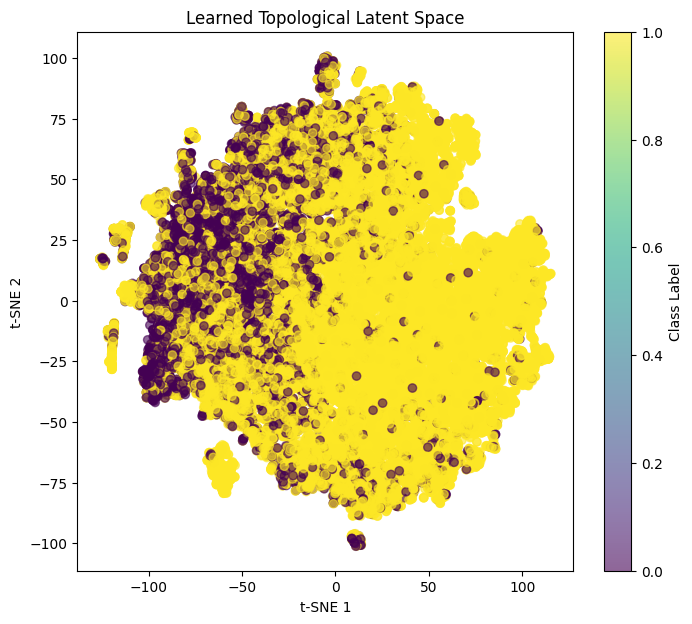

✅ Saved latent_space_tsne.png


In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,7))

scatter = plt.scatter(
    emb_2d[:,0],
    emb_2d[:,1],
    c=labels,
    alpha=0.6
)

plt.xlabel("t-SNE 1")

plt.ylabel("t-SNE 2")

plt.title(
    "Learned Topological Latent Space"
)

cbar = plt.colorbar(scatter)

cbar.set_label("Class Label")

plt.savefig(
    "learned_latent_space_tsne.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Saved latent_space_tsne.png")

In [48]:
np.save(
    "latent_embeddings.npy",
    embeddings
)

np.save(
    "latent_labels.npy",
    labels
)

print("✅ Saved embeddings")

✅ Saved embeddings


In [49]:
import tarfile

files_to_save = [
    "best_nnconv_model.pt",
    "training_loss.png",
    "validation_auc.png",
    "training_metrics.csv",
    "training_summary.txt",
    "learned_latent_space_tsne.png",
    "latent_embeddings.npy",
    "latent_labels.npy"
]

with tarfile.open(
    "nnconv_results_bundle.tar.gz",
    "w:gz"
) as tar:

    for file in files_to_save:
        tar.add(file)

print("✅ Bundle created")

✅ Bundle created


In [50]:
from google.colab import files

files.download(
    "nnconv_results_bundle.tar.gz"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()

all_preds = []
all_probs = []
all_labels = []
all_embeddings = []

with torch.no_grad():

    for data in test_loader:

        data = data.to(device)

        # Forward pass
        out = model(data)

        # Probabilities
        probs = torch.softmax(out, dim=1)[:,1]

        preds = probs > 0.5

        # Save outputs
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(data.y.cpu().numpy())

        # Extract graph embeddings
        x = model.conv1(
            data.x,
            data.edge_index,
            data.edge_attr
        )

        x = torch.relu(x)

        emb = torch.mean(x, dim=0)

        all_embeddings.append(
            emb.cpu().numpy()
        )

print("✅ Inference complete")

✅ Inference complete


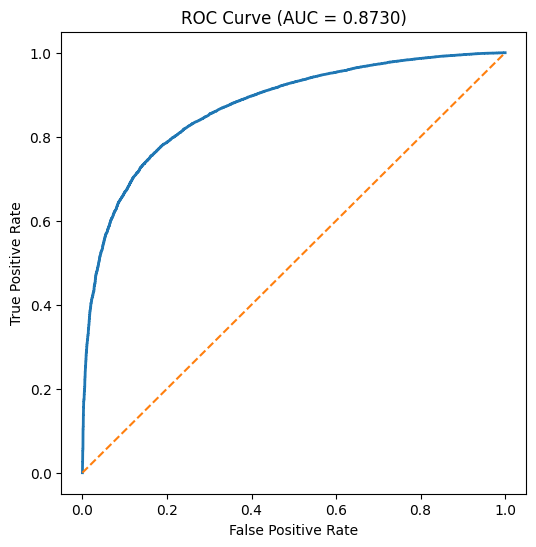

In [52]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")

plt.savefig("roc_curve.png", dpi=300)
plt.show()

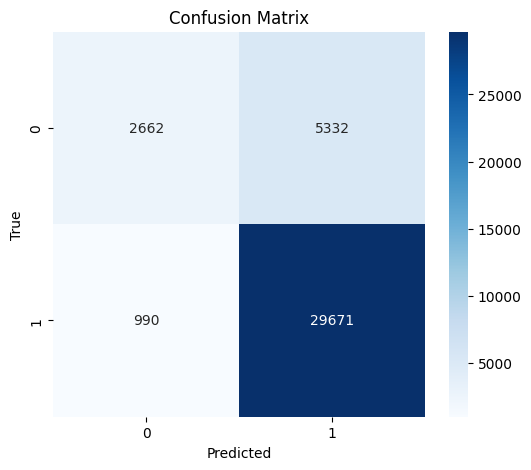

In [53]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

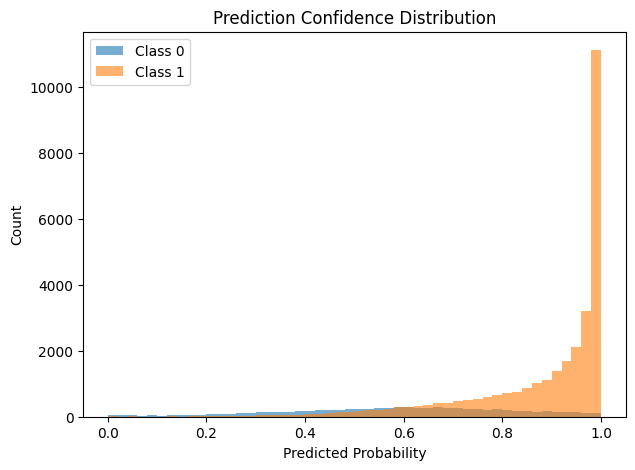

In [54]:
plt.figure(figsize=(7,5))

plt.hist(
    np.array(all_probs)[np.array(all_labels)==0],
    bins=50,
    alpha=0.6,
    label='Class 0'
)

plt.hist(
    np.array(all_probs)[np.array(all_labels)==1],
    bins=50,
    alpha=0.6,
    label='Class 1'
)

plt.xlabel("Predicted Probability")
plt.ylabel("Count")

plt.legend()

plt.title("Prediction Confidence Distribution")

plt.savefig("confidence_distribution.png", dpi=300)
plt.show()

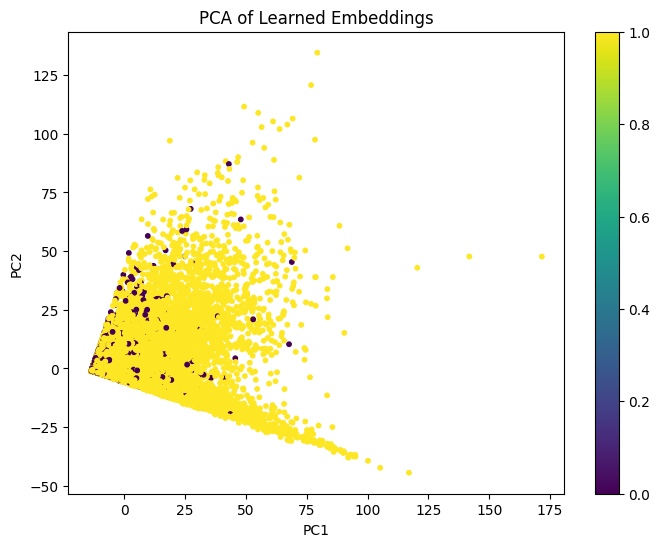

In [55]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=all_labels,
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA of Learned Embeddings")

plt.colorbar(scatter)

plt.savefig("pca_embeddings.png", dpi=300)
plt.show()

In [57]:
import tarfile

files_to_save = [
    "roc_curve.png",
    "confusion_matrix.png",
    "confidence_distribution.png",
    "pca_embeddings.png"
]

with tarfile.open(
    "physics_analysis_bundle.tar.gz",
    "w:gz"
) as tar:

    for file in files_to_save:
        tar.add(file)

print("✅ Physics analysis bundle saved")

✅ Physics analysis bundle saved


In [58]:
from google.colab import files

files.download(
    "physics_analysis_bundle.tar.gz"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>